# Projeto Introdução à Aprendizagem Automática 2025/2026

## Identificação do Grupo
- **Grupo:** A
- **Membros:**
  - Número [61863] - [Tiago Leite] (Horas: Xh, Contribuição: Y)
  - Número [61865] - [Rodrigo Frutuoso] (Horas: Xh, Contribuição: Y)
  - Número [61874] - [Simão Alexandre] (Horas: Xh, Contribuição: Y)


## Descrição das Variáveis (Spaceship Titanic)
- **PassengerId** - Id único para cada passageiro.
- **HomePlanet** - O planeta de onde o passageiro partiu.
- **CryoSleep** - Indica se o passageiro foi colocado em animação suspensa.
- **Cabin** - O número da cabine.
- **Destination** - O planeta para onde o passageiro vai.
- **Age** - Idade.
- **VIP** - Se pagou por serviço VIP especial.
- **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck** - Valores faturados pelo passageiro em diferentes serviços da nave.
- **Name** - Nome.
- **Transported** - Se o passageiro foi transportado para outra dimensão (Variável Alvo para O1).

## Enquadramento do problema

Este projeto usa o dataset `spaceship_data.csv` para resolver três objetivos distintos:

- **O1:** prever a variável `Transported`.
- **O2:** prever o valor gasto em `FoodCourt`.
- **O3:** prever a idade dos passageiros que foram transportados.

Classificação dos problemas:

- **O1:** classificação binária.
- **O2:** regressão.
- **O3:** regressão condicionada ao subconjunto de passageiros transportados.

A estratégia inicial será:

1. compreender as variáveis e a estrutura do dataset;
2. identificar valores em falta e tipos de atributos;
3. preparar o pré-processamento base para os modelos seguintes.

# Fase 1: Introdução e Análise Exploratória de Dados (EDA)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas para gráficos
sns.set_theme(style="whitegrid")

# Carregar os dados de treino
df = pd.read_csv('Projeto_IAA26_ST/spaceship_data.csv')

# Visualizar as primeiras linhas
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,4066_02,Europa,True,B/155/S,TRAPPIST-1e,22.0,False,0.0,0.0,0.0,0.0,0.0,Diramak Objeciane,True
1,8602_01,Earth,True,G/1396/P,TRAPPIST-1e,3.0,False,0.0,0.0,0.0,0.0,0.0,Robina Weissey,False
2,4181_06,Europa,False,C/133/P,55 Cancri e,41.0,True,0.0,9463.0,0.0,1022.0,1562.0,Ranan Frattyring,True
3,8112_01,Earth,False,F/1553/S,PSO J318.5-22,23.0,False,90.0,4.0,0.0,7.0,588.0,Benda Dickley,False
4,3152_01,Earth,True,G/496/S,TRAPPIST-1e,14.0,False,0.0,0.0,0.0,0.0,0.0,Therek Greeves,False


In [5]:
# Resumo da informação do dataset (tipos de dados, valores nulos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   6954 non-null   object 
 1   HomePlanet    6796 non-null   object 
 2   CryoSleep     6792 non-null   object 
 3   Cabin         6793 non-null   object 
 4   Destination   6807 non-null   object 
 5   Age           6806 non-null   float64
 6   VIP           6785 non-null   object 
 7   RoomService   6819 non-null   float64
 8   FoodCourt     6806 non-null   float64
 9   ShoppingMall  6784 non-null   float64
 10  Spa           6809 non-null   float64
 11  VRDeck        6809 non-null   float64
 12  Name          6784 non-null   object 
 13  Transported   6954 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 713.2+ KB


Dimensão do dataset: 6954 linhas e 14 colunas

Colunas:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

Valores em falta por coluna:


,missing_values,missing_pct
Name,170,2.44
ShoppingMall,170,2.44
VIP,169,2.43
CryoSleep,162,2.33
Cabin,161,2.32
HomePlanet,158,2.27
Age,148,2.13
FoodCourt,148,2.13
Destination,147,2.11
VRDeck,145,2.09



Resumo estatístico das variáveis numéricas:


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,6806.000000,6819.000000,6806.000000,6784.000000,6809.000000,6809.000000
mean,28.936967,224.105734,481.193947,177.626621,305.727566,306.249963
std,14.498980,664.362567,1693.383038,631.915796,1106.246652,1152.081336
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,45.500000,83.000000,26.000000,61.000000,47.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


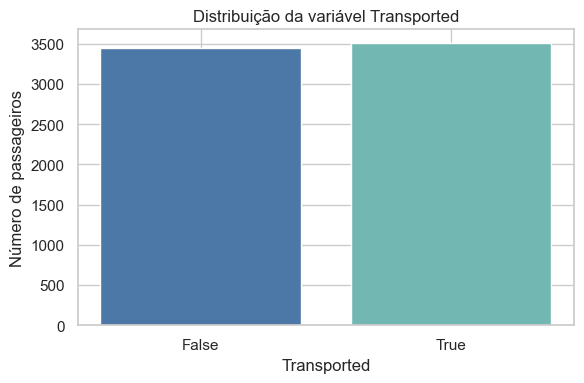

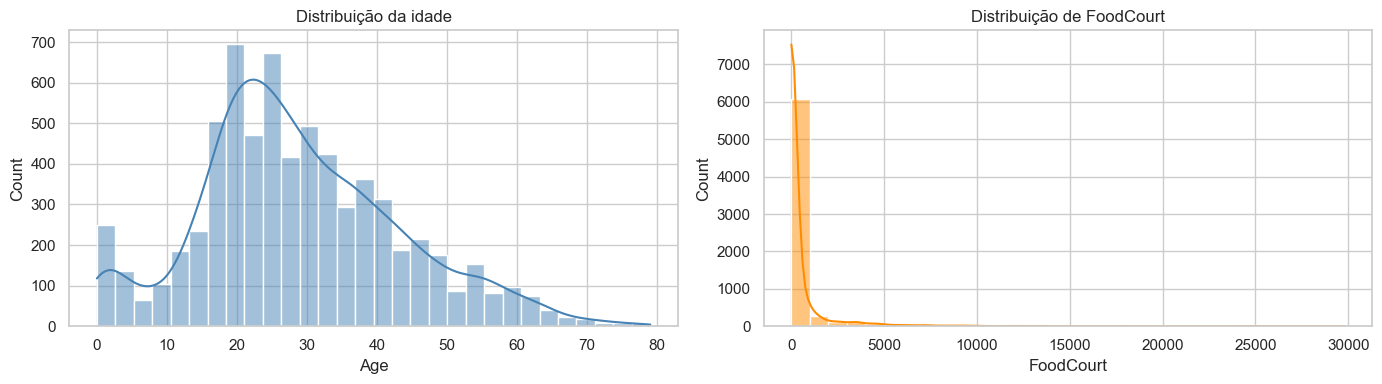

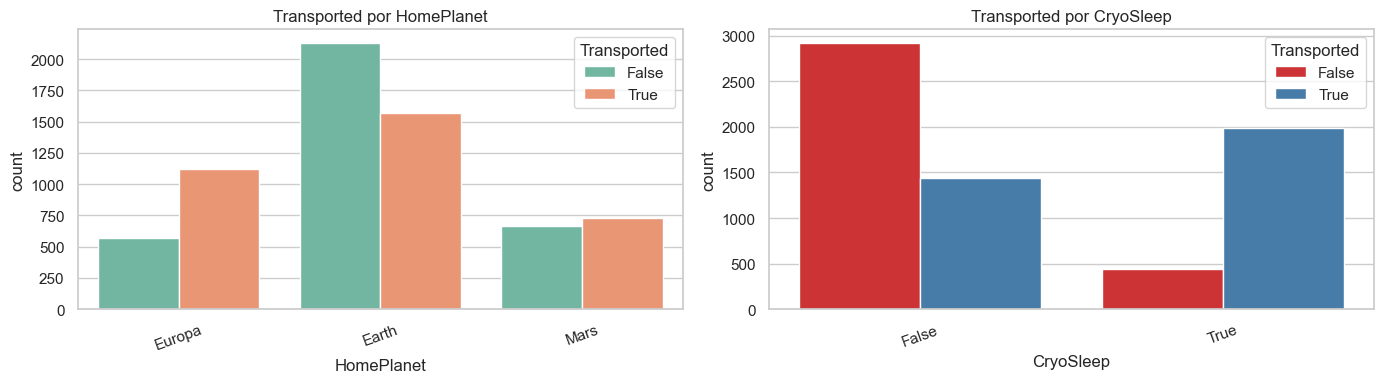

In [6]:
# Visão geral do dataset
print(f"Dimensão do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("\nColunas:")
print(df.columns.tolist())

# Valores em falta por coluna
missing_values = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_values / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'missing_values': missing_values,
    'missing_pct': missing_pct
})
missing_table = missing_table[missing_table['missing_values'] > 0]
print("\nValores em falta por coluna:")
display(missing_table)

# Resumo estatístico das variáveis numéricas
print("\nResumo estatístico das variáveis numéricas:")
display(df.describe())

# Distribuição da variável alvo do O1
transported_counts = df['Transported'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(transported_counts.index.astype(str), transported_counts.values, color=['#4c78a8', '#72b7b2'])
plt.title('Distribuição da variável Transported')
plt.xlabel('Transported')
plt.ylabel('Número de passageiros')
plt.tight_layout()
plt.show()

# Distribuição de algumas variáveis numéricas importantes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Age'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da idade')
axes[0].set_xlabel('Age')

sns.histplot(df['FoodCourt'], kde=True, bins=30, ax=axes[1], color='darkorange')
axes[1].set_title('Distribuição de FoodCourt')
axes[1].set_xlabel('FoodCourt')

plt.tight_layout()
plt.show()

# Relação simples entre Transported e algumas variáveis categóricas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=df, x='HomePlanet', hue='Transported', ax=axes[0], palette='Set2')
axes[0].set_title('Transported por HomePlanet')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='CryoSleep', hue='Transported', ax=axes[1], palette='Set1')
axes[1].set_title('Transported por CryoSleep')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## EDA inicial

Nesta fase vamos começar por perceber a estrutura do dataset, a presença de valores em falta e a distribuição das variáveis mais relevantes, incluindo a variável alvo do O1.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Criar uma cópia de trabalho para engenharia de variáveis
work_df = df.copy()

# Features derivadas a partir de Cabin
cabin_split = work_df['Cabin'].fillna('//').str.split('/', expand=True)
cabin_split = cabin_split.replace('', np.nan)
work_df['CabinDeck'] = cabin_split[0]
work_df['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
work_df['CabinSide'] = cabin_split[2]

# Separar variáveis explicativas e alvo base
base_target = 'Transported'
base_feature_columns = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'Age',
    'VIP',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    'CabinDeck',
    'CabinNum',
    'CabinSide'
]

X_base = work_df[base_feature_columns].copy()
y_base = work_df[base_target].copy()

# Identificar colunas numéricas e categóricas
numeric_features = X_base.select_dtypes(include=['number', 'float64', 'int64']).columns.tolist()
categorical_features = X_base.select_dtypes(exclude=['number', 'float64', 'int64']).columns.tolist()

print('Variáveis numéricas:', numeric_features)
print('Variáveis categóricas:', categorical_features)

# Transformadores para o pipeline base
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Pequeno resumo do que ficou preparado
print(f'Número de variáveis de entrada: {len(base_feature_columns)}')
print(f'Número de variáveis numéricas: {len(numeric_features)}')
print(f'Número de variáveis categóricas: {len(categorical_features)}')

Variáveis numéricas: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum']
Variáveis categóricas: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'CabinDeck', 'CabinSide']
Número de variáveis de entrada: 13
Número de variáveis numéricas: 7
Número de variáveis categóricas: 6


## Pré-processamento base

Vamos preparar uma base comum para os modelos seguintes: tratamento de valores em falta, codificação de variáveis categóricas, normalização das variáveis numéricas e criação de algumas features úteis a partir de `Cabin`.

In [8]:
# === Pré-processamento adicional e criação de features (comentado) ===

# - Criar o agregado total_spent
# - Tratar NA nos gastos (assumir que NA = 0 quando apropriado)
# - Adicionar indicadores de falta (*_na) para variáveis importantes
# - Normalizar strings das variáveis categóricas
# - Atualizar `X_base` para incluir as novas features

# 1) Contagem de NA antes das transformações (visão rápida)
print('Missing (antes) - subset de features base:')
display(work_df[base_feature_columns].isna().sum())

# 2) Agregados de gastos - lista das colunas relevantes
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

# Criar indicadores *_na para cada gasto (úteis se NA significar algo)
for c in spend_cols:
    work_df[c + '_na'] = work_df[c].isna().astype(int)

# Assumir que NA em gastos implica 'não usou' → preencher com 0 (prática comum neste dataset)
work_df[spend_cols] = work_df[spend_cols].fillna(0)

# total_spent: soma dos gastos (mantemos sem transformação; aplicar log1p depois se necessário)
work_df['total_spent'] = work_df[spend_cols].sum(axis=1)

# 3) Limpeza e normalização de strings nas categóricas antes da codificação
cat_cols = ['HomePlanet','Destination','CabinDeck','CabinSide','CryoSleep','VIP']
for c in cat_cols:
    # converter para string, remover espaços e normalizar para minúsculas
    work_df[c] = work_df[c].astype(str).str.strip().str.lower()
    # substituir representações de nan/none por 'missing' e preencher NA se existir
    work_df[c] = work_df[c].replace({'nan':'missing','none':'missing'})
    work_df[c] = work_df[c].fillna('missing')

# 4) Indicadores para variáveis numéricas com NA (Age, CabinNum)
work_df['Age_na'] = work_df['Age'].isna().astype(int)
work_df['CabinNum_na'] = work_df['CabinNum'].isna().astype(int)

# NOTA: não imputamos Age/CabinNum aqui (vamos imputar dentro do pipeline por mediana),
# apenas mantemos os indicadores que podem capturar sinal do fato de faltar.

# 5) Atualizar X_base para incluir as novas features geradas
additional = ['total_spent'] + [c + '_na' for c in spend_cols] + ['Age_na','CabinNum_na']
X_base = work_df[base_feature_columns + additional].copy()

# 6) Contagens de NA depois e resumo rápido de total_spent
print('\nMissing (depois) - X_base subset:')
display(X_base.isna().sum())
print('\nResumo rápido de total_spent:')
display(X_base['total_spent'].describe())

# Recomendações finais (em comentário):
# - A imputação final (mediana para numéricos, 'missing' para categóricas) deve ser feita dentro
#   do `preprocessor_base` usando `SimpleImputer` para evitar data leakage.
# - Se a distribuição de gastos for muito enviesada, aplicar `np.log1p` dentro do pipeline
#   ou clippagem antes.
# - Após estas transformações, executar 'smoke tests' com `preprocessor_base.fit_transform(X_train)`
#   e `preprocessor_base.transform(X_example)` para verificar shapes e ausência de NaN.

Missing (antes) - subset de features base:


HomePlanet      158
CryoSleep       162
Destination     147
Age             148
VIP             169
RoomService     135
FoodCourt       148
ShoppingMall    170
Spa             145
VRDeck          145
CabinDeck       161
CabinNum        161
CabinSide       161
dtype: int64


Missing (depois) - X_base subset:


HomePlanet           0
CryoSleep            0
Destination          0
Age                148
VIP                  0
RoomService          0
FoodCourt            0
ShoppingMall         0
Spa                  0
VRDeck               0
CabinDeck            0
CabinNum           161
CabinSide            0
total_spent          0
RoomService_na       0
FoodCourt_na         0
ShoppingMall_na      0
Spa_na               0
VRDeck_na            0
Age_na               0
CabinNum_na          0
dtype: int64


Resumo rápido de total_spent:


count     6954.000000
mean      1463.209232
std       2847.739366
min          0.000000
25%          0.000000
50%        721.000000
75%       1452.500000
max      35987.000000
Name: total_spent, dtype: float64

# Fase 2: Resolução dos Objetivos
## Objetivo 1 (O1): Prever a variável Transported

In [ ]:
import sys
!{sys.executable} -m ensurepip --default-pip
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install xgboost scikit-learn pandas numpy matplotlib seaborn

Dados: 6954 amostras, 13 features
Classes: {1: 3502, 0: 3452}
LogReg       - Accuracy: 0.7934  F1: 0.7932
AdaBoost     - Accuracy: 0.7985  F1: 0.7981
XGBoost      - Accuracy: 0.8070  F1: 0.8070


,Accuracy,F1-Score
LogReg,0.793357,0.793199
AdaBoost,0.798535,0.798100
XGBoost,0.807017,0.806967


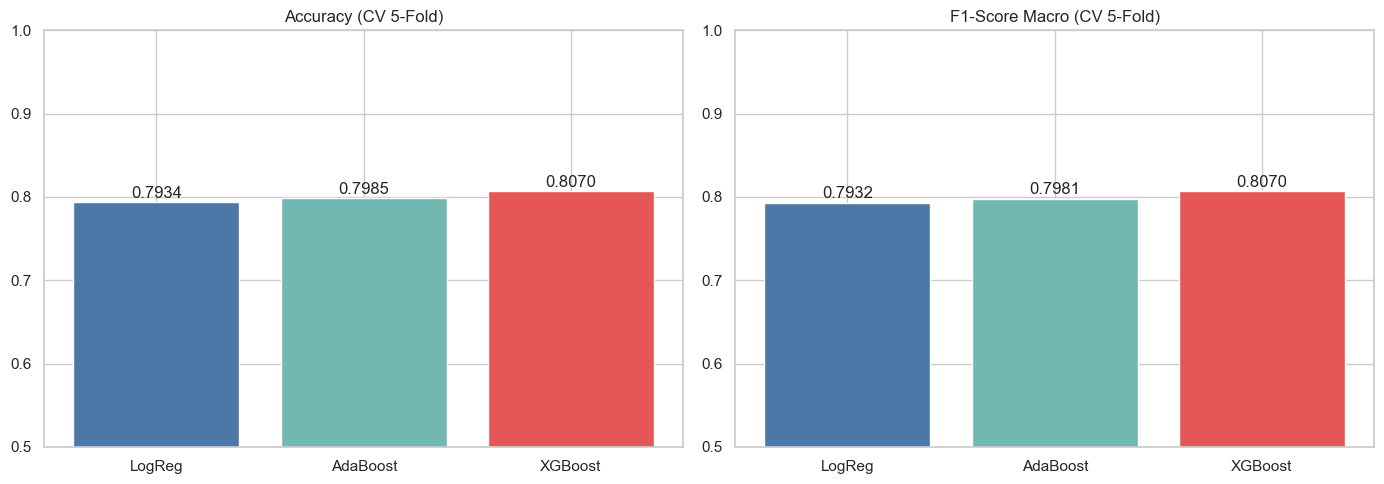


Melhor modelo (F1): XGBoost
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Melhores parametros: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 5, 'classifier__n_estimators': 50, 'classifier__subsample': 0.8}
Melhor F1 (CV): 0.8087


,params,mean_test_score,std_test_score,rank_test_score
42,"{'classifier__learning_rate': 0.2, 'classifier...",0.808674,0.011594,1
39,"{'classifier__learning_rate': 0.2, 'classifier...",0.808664,0.006079,2
26,"{'classifier__learning_rate': 0.1, 'classifier...",0.807839,0.008205,3
38,"{'classifier__learning_rate': 0.2, 'classifier...",0.807720,0.006198,4
27,"{'classifier__learning_rate': 0.1, 'classifier...",0.807623,0.008286,5
23,"{'classifier__learning_rate': 0.1, 'classifier...",0.807608,0.006588,6
36,"{'classifier__learning_rate': 0.2, 'classifier...",0.807229,0.009324,7
24,"{'classifier__learning_rate': 0.1, 'classifier...",0.806984,0.009770,8
22,"{'classifier__learning_rate': 0.1, 'classifier...",0.806960,0.005939,9
41,"{'classifier__learning_rate': 0.2, 'classifier...",0.806860,0.004432,10



Resultados no conjunto de exemplo:
  Accuracy:  0.8000
  F1-Score:  0.6875
                 precision    recall  f1-score   support

Not Transported       0.50      0.50      0.50         2
    Transported       0.88      0.88      0.88         8

       accuracy                           0.80        10
      macro avg       0.69      0.69      0.69        10
   weighted avg       0.80      0.80      0.80        10



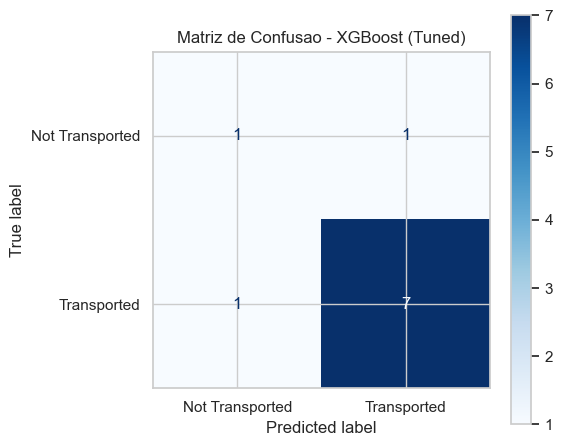

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Preparar dados
X_o1 = X_base.copy()
y_o1 = y_base.astype(int).copy()

print(f"Dados: {X_o1.shape[0]} amostras, {X_o1.shape[1]} features")
print(f"Classes: {y_o1.value_counts().to_dict()}")

# Helper para graficos
def plot_results(r, ylabel='score'):
    plt.figure(figsize=(1.2 * len(r), 5))
    b = plt.bar(r.keys(), r.values())
    plt.bar_label(b, fmt='%.4f')
    plt.xlabel('Modelo')
    plt.xticks(rotation=45)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# ================================================================
# Comparacao de 3 modelos (Stratified 5-Fold CV)
# ================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_acc = {}
results_f1 = {}

# Modelo 1: Logistic Regression (baseline)
pipe_lr = Pipeline([('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
results_acc['LogReg'] = cross_val_score(pipe_lr, X_o1, y_o1, cv=cv, scoring='accuracy').mean()
results_f1['LogReg'] = cross_val_score(pipe_lr, X_o1, y_o1, cv=cv, scoring='f1_macro').mean()
print(f"LogReg       - Accuracy: {results_acc['LogReg']:.4f}  F1: {results_f1['LogReg']:.4f}")

# Modelo 2: AdaBoost
pipe_ada = Pipeline([('preprocessor', preprocessor_base),
    ('classifier', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),n_estimators=100,random_state=42))])
results_acc['AdaBoost'] = cross_val_score(pipe_ada, X_o1, y_o1, cv=cv, scoring='accuracy').mean()
results_f1['AdaBoost'] = cross_val_score(pipe_ada, X_o1, y_o1, cv=cv, scoring='f1_macro').mean()
print(f"AdaBoost     - Accuracy: {results_acc['AdaBoost']:.4f}  F1: {results_f1['AdaBoost']:.4f}")

# Modelo 3: XGBoost
pipe_xgb = Pipeline([('preprocessor', preprocessor_base),
    ('classifier', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'))])
results_acc['XGBoost'] = cross_val_score(pipe_xgb, X_o1, y_o1, cv=cv, scoring='accuracy').mean()
results_f1['XGBoost'] = cross_val_score(pipe_xgb, X_o1, y_o1, cv=cv, scoring='f1_macro').mean()
print(f"XGBoost      - Accuracy: {results_acc['XGBoost']:.4f}  F1: {results_f1['XGBoost']:.4f}")

# Tabela de resultados
results_table = pd.DataFrame({'Accuracy': results_acc,'F1-Score': results_f1})
display(results_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4c78a8', '#72b7b2', '#e45756']
axes[0].bar(results_acc.keys(), results_acc.values(), color=colors)
axes[0].set_title('Accuracy (CV 5-Fold)')
axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(results_acc.values()):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center')
axes[1].bar(results_f1.keys(), results_f1.values(), color=colors)
axes[1].set_title('F1-Score Macro (CV 5-Fold)')
axes[1].set_ylim(0.5, 1.0)
for i, v in enumerate(results_f1.values()):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center')
plt.tight_layout()
plt.show()

# Melhor modelo
best_name = max(results_f1, key=results_f1.get)
print(f"\nMelhor modelo (F1): {best_name}")

# ================================================================
# Tuning de hiperparametros do melhor modelo
# ================================================================
if best_name == 'XGBoost':
    param_grid = { 'classifier__n_estimators': [50, 100, 200],
                   'classifier__max_depth': [3, 5, 7],
                   'classifier__learning_rate': [0.01, 0.1, 0.2],
                   'classifier__subsample': [0.8, 1.0],}
    base_pipe = Pipeline([('preprocessor', preprocessor_base),
        ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))])
elif best_name == 'AdaBoost':
    param_grid = { 'classifier__n_estimators': [50, 100, 200, 300],
                   'classifier__learning_rate': [0.01, 0.1, 0.5, 1.0],}
    base_pipe = Pipeline([ ('preprocessor', preprocessor_base),
        ('classifier', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), random_state=42))])
else:
    param_grid = { 'classifier__C': [0.01, 0.1, 1.0, 10.0],
                   'classifier__penalty': ['l1', 'l2'],
                   'classifier__solver': ['liblinear'],}
    base_pipe = Pipeline([ ('preprocessor', preprocessor_base),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))])

grid = GridSearchCV(base_pipe, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_o1, y_o1)

print(f"\nMelhores parametros: {grid.best_params_}")
print(f"Melhor F1 (CV): {grid.best_score_:.4f}")

tuning_df = pd.DataFrame(grid.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
display(tuning_df.sort_values('rank_test_score').head(10))

# ================================================================
# Previsao no conjunto de exemplo (space_ex_o1.csv)
# ================================================================
ex_o1 = pd.read_csv('Projeto_IAA26_ST/space_ex_o1.csv')
ex_o1_y = pd.read_csv('Projeto_IAA26_ST/space_ex_o1_y.csv')

# Preparar features (mesma engenharia que X_base)
ex_work = ex_o1.copy()
cs = ex_work['Cabin'].fillna('//').str.split('/', expand=True).replace('', np.nan)
ex_work['CabinDeck'] = cs[0]
ex_work['CabinNum'] = pd.to_numeric(cs[1], errors='coerce')
ex_work['CabinSide'] = cs[2]

X_ex = ex_work[base_feature_columns].copy()

y_ex_true = ex_o1_y['Transported'].astype(int)

best_model = grid.best_estimator_
y_ex_pred = best_model.predict(X_ex)

acc_ex = accuracy_score(y_ex_true, y_ex_pred)
f1_ex = f1_score(y_ex_true, y_ex_pred, average='macro')

print(f"\nResultados no conjunto de exemplo:")
print(f"  Accuracy:  {acc_ex:.4f}")
print(f"  F1-Score:  {f1_ex:.4f}")
print(classification_report(y_ex_true, y_ex_pred, target_names=['Not Transported', 'Transported']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_ex_true, y_ex_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Transported', 'Transported']).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Matriz de Confusao - {best_name} (Tuned)')
plt.tight_layout()
plt.show()

## Objetivo 2 (O2): Prever o valor dispendido no FoodCourt

In [10]:
# Código para o Objetivo 2...
# Objetivo 2: Prever FoodCourt (compacto, sem leakage)
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1) Preparação rápida: preencher gastos e criar total_spent_excl_food
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
work_df[spend_cols] = work_df[spend_cols].fillna(0)
work_df['total_spent_excl_food'] = work_df[['RoomService','ShoppingMall','Spa','VRDeck']].sum(axis=1)

# 2) Features/target (remover FoodCourt para evitar leakage)
target = 'FoodCourt'
features = [c for c in X_base.columns if c != 'FoodCourt' and c != 'total_spent']
if 'total_spent_excl_food' not in features:
    features.append('total_spent_excl_food')
X_o2 = work_df[features].copy()
y_o2 = work_df[target].fillna(0).copy()
print(f'X_o2 shape: {X_o2.shape}')
display(X_o2.head())

# 3) Preprocessor (reusar transformers definidos anteriormente)
numeric_feats = X_o2.select_dtypes(include=['number']).columns.tolist()
categorical_feats = X_o2.select_dtypes(exclude=['number']).columns.tolist()
preprocessor_o2 = ColumnTransformer([
    ('num', numeric_transformer, numeric_feats),
    ('cat', categorical_transformer, categorical_feats)
], remainder='drop')

# 4) Pipelines candidatos
pipe_ridge = Pipeline([('preprocessor', preprocessor_o2), ('regressor', Ridge(random_state=42))])
pipe_rf = Pipeline([('preprocessor', preprocessor_o2), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
pipe_xgb = Pipeline([('preprocessor', preprocessor_o2), ('regressor', XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0))])
models = {'Ridge': pipe_ridge, 'RandomForest': pipe_rf, 'XGBoost': pipe_xgb}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 5) Avaliar com CV (RMSE/MAE/R2)
results = []
for name, mdl in models.items():
    try:
        neg_mse = cross_val_score(mdl, X_o2, y_o2, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
        rmse = np.sqrt(-neg_mse).mean()
        mae = -cross_val_score(mdl, X_o2, y_o2, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1).mean()
        r2 = cross_val_score(mdl, X_o2, y_o2, cv=cv, scoring='r2', n_jobs=-1).mean()
    except Exception as e:
        print(f'Erro ao avaliar {name}: {e}')
        rmse = mae = r2 = np.nan
    results.append({'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2})

results_df = pd.DataFrame(results).set_index('model')
print('\nResultados (CV):')
display(results_df)

# 6) Tuning rápido XGBoost
param_grid = {'regressor__n_estimators': [50, 100], 'regressor__max_depth': [3, 6], 'regressor__learning_rate': [0.05, 0.1]}
grid = GridSearchCV(pipe_xgb, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_o2, y_o2)
best_xgb = grid.best_estimator_
best_rmse = np.sqrt(-grid.best_score_)
print(f'XGBoost tuned CV-RMSE: {best_rmse:.4f}')

# 7) Selecionar e treinar modelo final (no conjunto completo) e salvar artefactos
best_candidate = results_df['rmse'].idxmin() if not results_df['rmse'].isna().all() else 'XGBoost'
candidate_model = models.get(best_candidate, pipe_xgb)
final_model = best_xgb if best_rmse < (results_df.loc['XGBoost','rmse'] if 'XGBoost' in results_df.index else np.inf) else candidate_model
final_name = 'XGBoost_tuned' if final_model is best_xgb else best_candidate
print(f'Final model: {final_name}')
final_model.fit(X_o2, y_o2)
os.makedirs('models', exist_ok=True)
joblib.dump(final_model, 'models/o2_best_regressor.joblib')
joblib.dump(preprocessor_o2, 'models/preprocessor_o2.joblib')
print('Modelos guardados em ./models')

# 8) Hold-out sanity check (20%)
X_tr, X_val, y_tr, y_val = train_test_split(X_o2, y_o2, test_size=0.2, random_state=42)
final_model.fit(X_tr, y_tr)
y_val_pred = final_model.predict(X_val)
# Compatibilidade: calcular RMSE manualmente (algumas versões do sklearn não aceitam 'squared' arg)
y_true = np.ravel(y_val)
y_pred = np.ravel(y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
print('Hold-out RMSE:', rmse_val)
display(pd.DataFrame({'y_true': y_val.head(10).values, 'y_pred': y_val_pred[:10]}))

# Nota: para resultados finais, usar nested CV ou hold-out + CV para tuning.


X_o2 shape: (6954, 20)


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,ShoppingMall,Spa,VRDeck,CabinDeck,CabinNum,CabinSide,RoomService_na,FoodCourt_na,ShoppingMall_na,Spa_na,VRDeck_na,Age_na,CabinNum_na,total_spent_excl_food
0,europa,true,trappist-1e,22.0,false,0.0,0.0,0.0,0.0,b,155.0,s,0,0,0,0,0,0,0,0.0
1,earth,true,trappist-1e,3.0,false,0.0,0.0,0.0,0.0,g,1396.0,p,0,0,0,0,0,0,0,0.0
2,europa,false,55 cancri e,41.0,true,0.0,0.0,1022.0,1562.0,c,133.0,p,0,0,0,0,0,0,0,2584.0
3,earth,false,pso j318.5-22,23.0,false,90.0,0.0,7.0,588.0,f,1553.0,s,0,0,0,0,0,0,0,685.0
4,earth,true,trappist-1e,14.0,false,0.0,0.0,0.0,0.0,g,496.0,s,0,0,0,0,0,0,0,0.0



Resultados (CV):


,rmse,mae,r2
model,,,
Ridge,1472.708409,721.537459,0.220267
RandomForest,1359.320738,410.725764,0.333843
XGBoost,1379.941529,419.493517,0.311736


Fitting 5 folds for each of 8 candidates, totalling 40 fits
XGBoost tuned CV-RMSE: 1321.6715
Final model: XGBoost_tuned
Modelos guardados em ./models
Hold-out RMSE: 976.0042562255143


,y_true,y_pred
0,12.0,299.184143
1,7069.0,3462.773438
2,0.0,107.503563
3,0.0,99.217514
4,0.0,27.595085
5,0.0,110.594803
6,0.0,13.085190
7,17.0,87.798782
8,2.0,110.594803
9,0.0,14.535511


## Objetivo 3 (O3): Prever a idade dos passageiros transportados

In [7]:
# Código para o Objetivo 3...

# Fase 3: Importância dos Atributos (O4)

In [8]:
# Código para extrair e desenhar gráficos da importância dos atributos dos melhores modelos acima...

# Fase 4: Discussão e Conclusões
Escrevam aqui as conclusões finais do projeto e respondam à pergunta do O3.